In [2]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import cartopy.crs as ccrs
import pysplit
import geopandas as gpd


In [3]:
from __future__ import division

#### Create a dataframe including the position and time of the backward trajectory you want to run (the following takes SGP as an example

In [11]:
import pandas as pd

data = {
    'year': [2018] * 6,
    'month': [6] * 6,
    'day': [4, 5, 6, 7, 8, 9, ],
    'lat': [36.60] * 6,
    'lon': [-97.487] * 6
}

df = pd.DataFrame(data)

In [12]:
df

,year,month,day,lat,lon
0,2018,6,4,36.6,-97.487
1,2018,6,5,36.6,-97.487
2,2018,6,6,36.6,-97.487
3,2018,6,7,36.6,-97.487
4,2018,6,8,36.6,-97.487
5,2018,6,9,36.6,-97.487


In [13]:
year = df['year']
month = df['month']
day = df['day']
lat = df['lat']
lon = df['lon']

In [14]:
working_dir = r'/data/ggong/hysplit/working'
output_dir = r'/data/ggong/hysplit/output_test/'
meteo_dir = r'/data/ggong/SGP'

for i in range(0,4):
    pysplit.generate_bulktraj(basename = str(lat[i])+str(lon[i]), 
                              hysplit_working = working_dir,
                              output_dir = output_dir, 
                              meteo_dir = meteo_dir,
                              years = [year[i]],
                              months = [month[i]],
                              hours = list(range(0,24)),  
                              altitudes = [5000], 
                              coordinates = (lat[i], lon[i]), 
                              run = -96,
                              monthslice = slice(day[i]-1,(day[i])),
                              meteo_bookends=([1], [1]),
                              get_clipped=False, 
                              get_reverse=False,
                              meteoyr_2digits=True,
                              outputyr_2digits=False,
                              hysplit = r'/data/shared_code/hysplit/exec/hyts_std')

 HYSPLIT - Initialization
 HYSPLIT version: hysplit.v5.4.2
 Last Changed Date: 2025-05-14
  NOTICE: using namelist file SETUP.CFG
 Calculation Started ... please be patient
 Percent complete:   1.0
 Percent complete:   2.1
 Percent complete:   3.1
 Percent complete:   4.2
 Percent complete:   5.2
 Percent complete:   6.2
 Percent complete:   7.3
 Percent complete:   8.3
 Percent complete:   9.4
 Percent complete:  10.4
 Percent complete:  11.5
 Percent complete:  12.5
 Percent complete:  13.5
 Percent complete:  14.6
 Percent complete:  15.6
 Percent complete:  16.7
 Percent complete:  17.7
 Percent complete:  18.8
 Percent complete:  19.8
 Percent complete:  20.8
 Percent complete:  21.9
 Percent complete:  22.9
 Percent complete:  24.0
 Percent complete:  25.0
 Percent complete:  26.0
 Percent complete:  27.1
 Percent complete:  28.1
 Percent complete:  29.2
 Percent complete:  30.2
 Percent complete:  31.2
 Percent complete:  32.3
 Percent complete:  33.3
 Percent complete:  34.4
 P

In [15]:
trajgroup = pysplit.make_trajectorygroup(r'/data/ggong/hysplit/output_test/*jun5000*')
print("number of 5000-m jun trajectories:",trajgroup.trajcount)

number of 5000-m jun trajectories: 144


In [16]:
trajgroup.trajectories[0].data

,Timestep,Pressure,Temperature,Mixing_Depth,Relative_Humidity,geometry,DateTime,Temperature_C
Timestep,,,,,,,,
0.0,0.0,539.1,268.4,1456.1,36.0,POINT Z (-97.487 36.6 5000),2018-06-04 00:00:00,-4.75
-1.0,-1.0,541.1,268.8,1584.1,34.0,POINT Z (-97.786 36.748 4950),2018-06-03 23:00:00,-4.35
-2.0,-2.0,541.7,268.9,1691.2,33.4,POINT Z (-98.105 36.909 4904.3),2018-06-03 22:00:00,-4.25
-3.0,-3.0,533.8,267.9,1583.6,29.1,POINT Z (-98.449 37.077 4970.8),2018-06-03 21:00:00,-5.25
-4.0,-4.0,521.6,266.2,1574.2,33.2,POINT Z (-98.81 37.242 5055.2),2018-06-03 20:00:00,-6.95
...,...,...,...,...,...,...,...,...
-61.0,-61.0,507.5,267.1,589.7,19.1,POINT Z (-117.245 21.604 5769),2018-06-01 11:00:00,-6.05
-62.0,-62.0,509.1,267.4,606.1,18.7,POINT Z (-117.369 21.217 5746.1),2018-06-01 10:00:00,-5.75
-63.0,-63.0,511.7,267.7,610.7,19.3,POINT Z (-117.469 20.845 5712.3),2018-06-01 09:00:00,-5.45


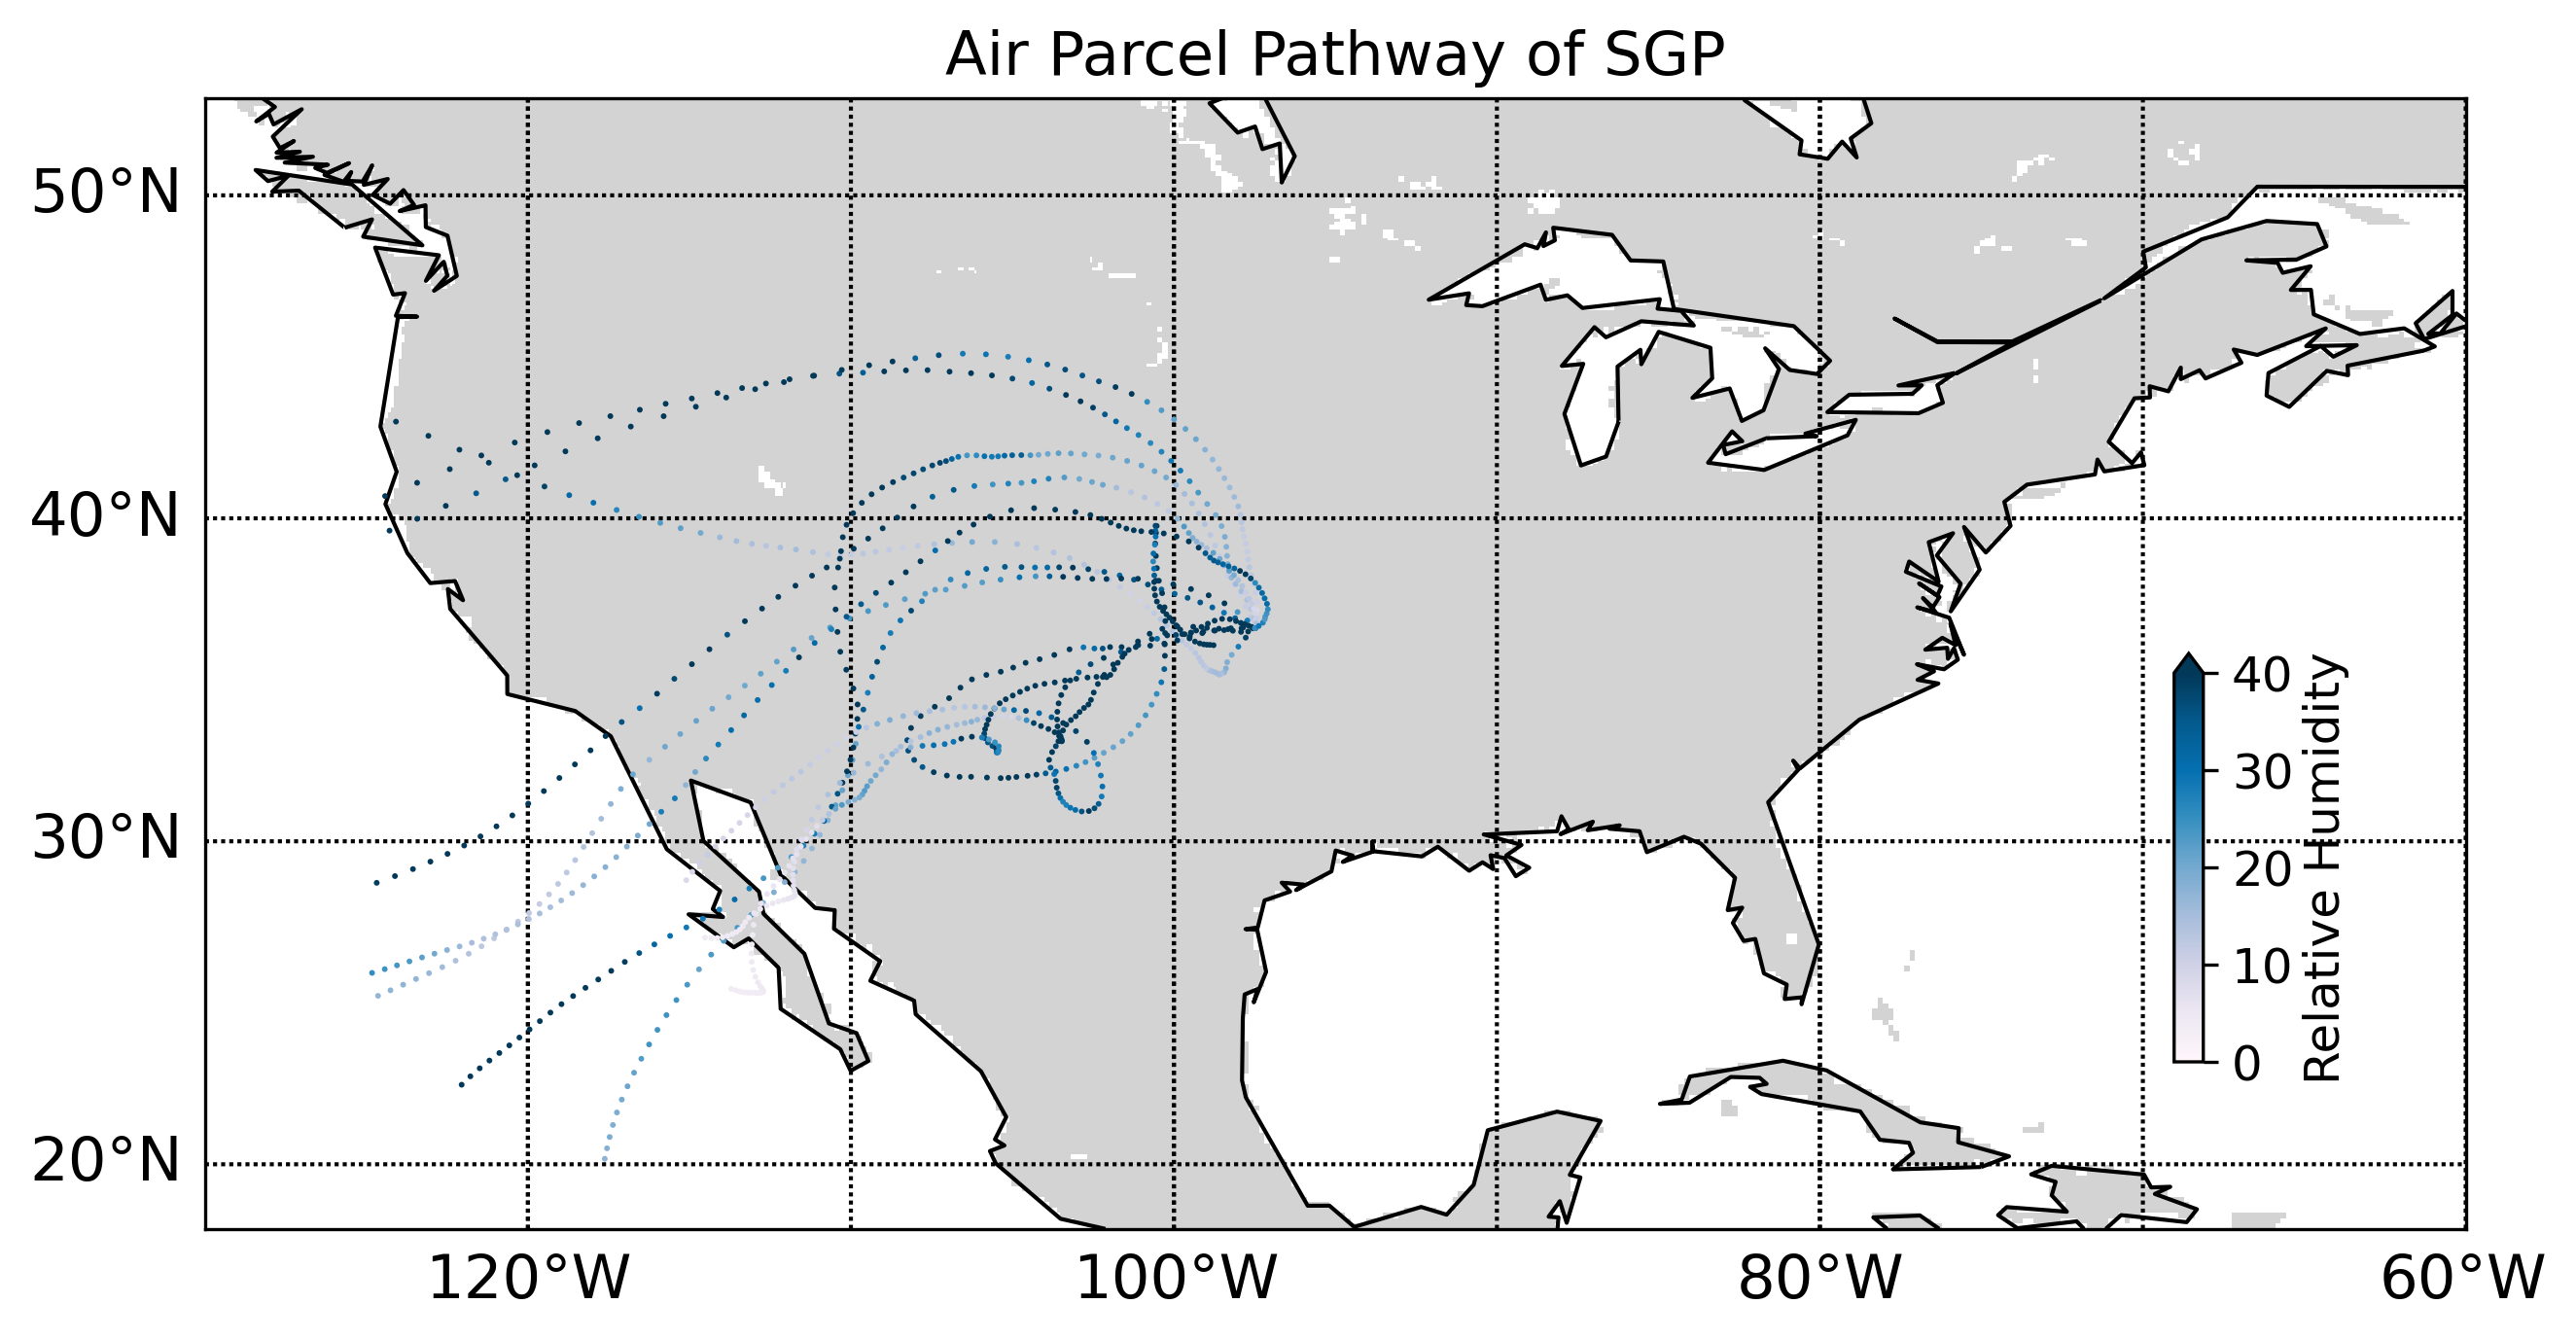

In [17]:
mapcorners = [-130, 18, -60, 53]
standard_pm = None
fig, ax = plt.subplots(figsize=(10,7),dpi=300)

bmap_params = pysplit.MapDesign(mapcorners, 
                                standard_pm, 
                                projection = 'cyl',
                                mapcolor = None, 
                                latlon_spacing = (10,10),
                                latlon_labelspacing=(10,20),
                                lon_labels=["bottom"], 
                                latlon_fs=15,
                                drawoutlines=False,
                                resolution="c",
                                )

bmap = bmap_params.make_basemap(ax=ax)
bmap.drawlsmask(land_color = "#d3d3d3", ocean_color="white",)
bmap.drawcoastlines()
plt.title('Air Parcel Pathway of SGP',fontsize =15)
for traj in trajgroup[::12]:

    mappable = pysplit.traj_scatter(
        traj.data.Relative_Humidity.astype(np.float64).values,
        traj.data.geometry.apply(lambda p: p.x).values,
        traj.data.geometry.apply(lambda p: p.y).values,
        bmap, colormap=plt.cm.PuBu,size=2,
        vmin=0, vmax=40, suppress_printmsg=False)

cax_position = [0.80, 0.3, 0.01, 0.2]
cax = fig.add_axes(cax_position)
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical', extend='max')

cbar.ax.tick_params(axis='both', which='both', width=0.8, labelsize=12)
cbar.set_label('Relative Humidity', rotation=90, va='center', fontsize=12, labelpad=8)


plt.show()

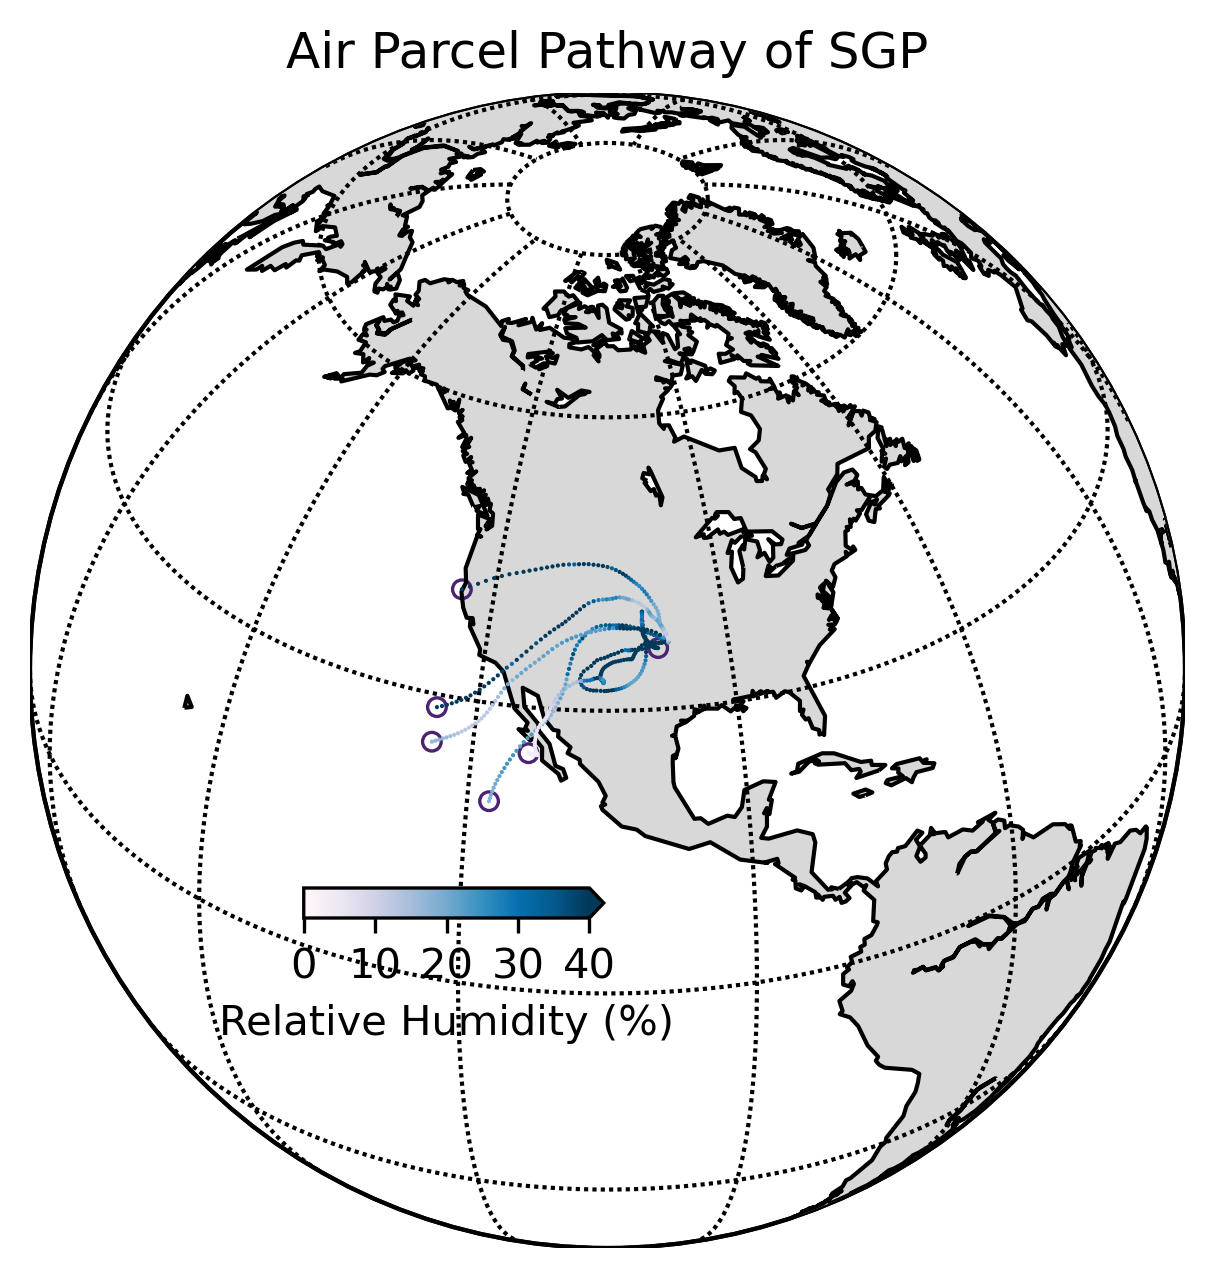

In [18]:


# plot
fig, ax = plt.subplots(figsize=(5,5),dpi=300)
map = Basemap(projection='ortho', lat_0=34, lon_0=-105, resolution='c',ax=ax)
map.drawcoastlines(linewidth=1)
map.fillcontinents(color='#d8d8d8', lake_color='#FFFFFF')
map.drawmapboundary(fill_color='#FFFFFF')
map.drawmeridians(np.arange(0, 360, 30))
map.drawparallels(np.arange(-90, 90, 30))

plt.title('Air Parcel Pathway of SGP')
# Add trajectories to the map
for traj in trajgroup[::24]:
    mappable= pysplit.traj_scatter(
              traj.data.Relative_Humidity.astype(np.float64).values,
              traj.data.geometry.apply(lambda p: p.x).values,
              traj.data.geometry.apply(lambda p: p.y).values,
              map, colormap=plt.cm.PuBu, size=1,
              vmin=0, vmax=40, suppress_printmsg=False)

    last_point = traj.data.geometry.iloc[-1]
    x_last, y_last = map(last_point.x, last_point.y)
    map.scatter(x_last, y_last, marker='o', s=20, facecolor='none', edgecolor='#4c2371', lw=0.8, label='Moisture Source')

# add colorbar
cax = fig.add_axes([0.31, 0.33, 0.2, 0.02])
cbar = plt.colorbar(mappable, cax=cax, orientation='horizontal',extend='max')
cbar.set_label('Relative Humidity (%)')
cbar.set_ticks([0, 10, 20, 30, 40])

if __name__ == "__main__":
    plt.show()